### ANN Regression

In [60]:
import pandas as pd
import numpy as np

In [61]:
df = pd.read_csv("powerplant_data.csv")

In [62]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [63]:
# AT = temperature
# V = vaccum
# AP = pressure
# RH = humidity

# PE = produced energy

#### Load the data

In [64]:
# Load the data
X = df.drop("PE", axis=1)
y = df["PE"]

In [65]:
# Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
# Scaling is necessary for ANN
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [67]:
type(X_train_scaled) # x_train_scaled = numpy array(pytorch expects this for tensor)

numpy.ndarray

In [68]:
type(y_train) # y_train = pd.series (convert this to (n,1) ndarray using .view(-1,1))

pandas.core.series.Series

#### Convert data to tensors

In [ ]:
# Convert data to tensors
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32) 
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1) # convert to (n,1) ndarray

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [70]:
X_test_tensor # tensors are stored in RAM

tensor([[ 1.3450,  0.2387, -1.2866, -1.1053],
        [ 0.8110,  1.3627, -0.7414,  0.2649],
        [-0.2437, -0.7390,  1.9997, -0.1971],
        ...,
        [-0.6707, -1.1590, -0.2995, -0.1065],
        [ 1.3142,  1.3375, -0.8735, -0.4429],
        [-0.2611, -0.2702,  0.3743,  1.1065]])

#### TensorDataset and DataLoader

In [71]:
# TensorDataset and DataLoader
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [72]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

### Deep Learning

#### Build our ANN model

In [73]:
# Build our ANN model

class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        
        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6), # out_features = 6(6 neurons in each hidden layer, produces 6 outputs)
            nn.ReLU(),
            
            # 2nd hidden layer
            nn.Linear(6,6), # here in_features=6(outputs from previous hidden layer), out_features =6(6 outputs from 6 neuron in this layer)
            nn.ReLU(),
            
            # output layer
            nn.Linear(6, 1), # 1 output for regression            
        )
    
    def forward(self, x):
        return self.model(x)

In [74]:
import torch.optim as optim

model = ANN()

# loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

#### Train the ANN

In [75]:
# Train the ANN

train_losses =[]
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs): # for 100 epochs
    model.train()
    running_loss = 0.0 # total training loss for 1 epoch
    
    for xb, yb in train_loader: # for all batches
        # xb = features of 1 batch
        # yb = labels of 1 batch
        
        optimizer.zero_grad() # for every batch, gradient is computed again from fresh
        
        outputs = model(xb)  # forward prop: predicted outputs for this batch
        loss = criterion(outputs, yb)  # compute loss
        loss.backward()  # back prop: compute gradients
        optimizer.step()  # params update
        
        running_loss += loss.item() # loss is a tensor => convert to python float value
        
        
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)
    
    
    # Validation
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():  # no gradients compute (speeds up validation process, saves memory)
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss.item()
            
        epoch_val_loss = running_val_loss / len(test_loader)
        val_losses.append(epoch_val_loss)
        
        print(f"epoch ${epoch+1}/{epoch} ==> train loss = ${epoch_train_loss} & val loss = ${epoch_val_loss}")
        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch $1/0 ==> train loss = $205949.1732421875 & val loss = $203963.0578125
epoch $2/1 ==> train loss = $198974.5349609375 & val loss = $190867.14739583334
epoch $3/2 ==> train loss = $176834.43131510416 & val loss = $159351.34010416668
epoch $4/3 ==> train loss = $137149.15068359376 & val loss = $113518.80338541667
epoch $5/4 ==> train loss = $89845.25100911458 & val loss = $67887.23307291667
epoch $6/5 ==> train loss = $50503.51654459636 & val loss = $36653.24401041667
epoch $7/6 ==> train loss = $28060.165197753908 & val loss = $22114.457486979165
epoch $8/7 ==> train loss = $18757.075937906902 & val loss = $16341.486197916667
epoch $9/8 ==> train loss = $14737.02205810547 & val loss = $13193.965022786459
epoch $10/9 ==> train loss = $12044.355584716797 & val loss = $10668.933927408854
epoch $11/10 ==> train loss = $9688.118575032551 & val loss = $8426.089184570312
epoch $12/11 ==> train loss = $7593.928207397461 & val loss = $6458.1957316080725
epoch $13/12 ==> train loss = $5772.7

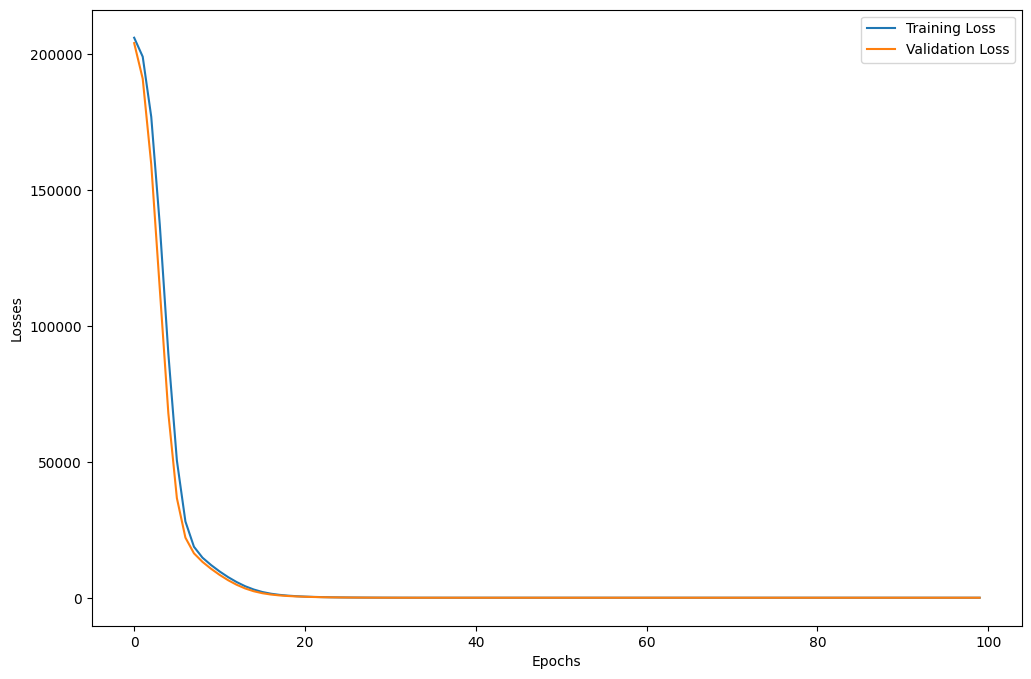

In [76]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.figure(figsize=(12,8))
plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

#### Loading the best model

In [ ]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt")) # load saved best parameters into the model

<All keys matched successfully>

#### Evaluate

In [81]:
# Evaluate our model

model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)
    
    train_mse_loss = criterion(train_pred, y_train_tensor)
    test_mse_loss = criterion(test_pred, y_test_tensor)
    
print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())


Training MSE: 18.778221130371094
Testing MSE: 17.790334701538086


In [82]:
from sklearn.metrics import r2_score

print("r^2 score:", r2_score(y_test, test_pred))

r^2 score: 0.9378273719386732


In [84]:
predicted_df = pd.DataFrame(test_pred.numpy(), columns= ["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns= ["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,436.239655,433.27
1,436.699677,438.16
2,461.792938,458.42
3,475.814453,480.82
4,436.661102,441.41
...,...,...
1909,451.176605,456.70
1910,432.383392,438.04
1911,466.349915,467.80
1912,431.576141,437.14


### Compare with Linear Regression

In [79]:
# Using Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

linear = LinearRegression()
linear.fit(X_train_scaled, y_train)
y_pred = linear.predict(X_test_scaled)

# Evaluate
print("Linear Regression Model")
print("r^2 score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


Linear Regression Model
r^2 score: 0.9314747936670361
MSE: 19.60808532568382
